In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [ ]:
QiskitRuntimeService.save_account(channel='ibm_quantum_platform', instance = 'crn:v1:bluemix:public:quantum-computing:us-east:a/7122cb8d4e5148bd8f3a58292620d4cf:abf27454-09ac-4753-a3d0-9b0da10cdf09::', token='7jyKQAGgnppLAdmxUAPQsQDOJ6v00y3-GIQjW42pLazn', overwrite=True, set_as_default=True)
service = QiskitRuntimeService()

backend=service.backend("ibm_fez")
print(backend.name)

sampler=Sampler(mode=backend)

ibm_fez


In [ ]:
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

In [ ]:
noise_model=NoiseModel.from_backend(backend)

In [ ]:
backend_sim=AerSimulator(noise_model=noise_model)
sampler_sim=BackendSamplerV2(backend=backend_sim)

In [ ]:
from qiskit import QuantumCircuit

In [ ]:
from qiskit.transpiler.passes.optimization.light_cone import ZGate
from qiskit.circuit.library import MCMTGate

In [ ]:
def oracle(marked_item):

  if not isinstance(marked_item,list):
    marked_item=[marked_item]

  num_qubits=len(marked_item[0])

  qc=QuantumCircuit(num_qubits)

  for target in marked_item:
    rev_target=target[::-1]

    zero_indices=[ind for ind in range(num_qubits) if rev_target.startswith('0',ind)]
    qc.x(zero_indices)
    qc.compose(MCMTGate(ZGate(),num_qubits-1,1),inplace=True)
    qc.x(zero_indices)
  return qc

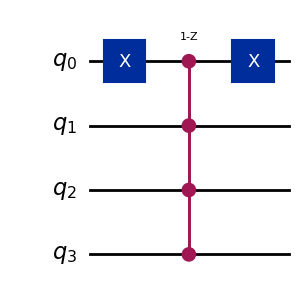

In [ ]:
marked_item=['1110']
oracle_circuit=oracle(marked_item)
oracle_circuit.draw(output='mpl')

In [ ]:
from qiskit.visualization import plot_distribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

circuit_isa = pm.run(oracle_circuit)

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
sampler.options.default_shots = 10_000

# Add measurements to circuit_isa if it doesn't have them
if circuit_isa.num_clbits == 0:
    circuit_isa.measure_all()

result = sampler.run([circuit_isa]).result()
dist = result[0].data.meas.get_counts()

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with a larger size to give more room for the plot elements
plt.figure(figsize=(10, 6))
plot_distribution(dist)
plt.show()

KeyboardInterrupt: 

<Figure size 1000x600 with 0 Axes>